# **Tuning the dropout**

## ⚙️ **Notbook config**

In [ ]:
# EDIT BEFORE USE
KAGGLE_API_PATH = "drive/MyDrive/[2025-2026] AN2DL/Challenges/"+"kaggle.json" # Google Drive path to your kaggle.json API credential file
SUBMIT_PREDICTION = True # Set to true to automatically send the submission to Kaggle
TRAIN_ON_WHOLE_SET = False # Set to true only the last day of the challenge to increase score of final selected model

# PARAMETERS
RESIZE_DIMENSION = [32, 32] # Resize width and height.
BATCH_SIZE = 32
SPLIT_RATIO = 0.2 # Percentage of Validation set (e.g. 0.2 => 80% train, 20% validation)

# EDIT WITH CARE
IMAGES_PATH = "./an2dl2526c2v2/train_data"
SUBMISSION_IMAGES_PATH = "./an2dl2526c2v2/test_data"
LABELS_PATH = "./an2dl2526c2v2/"+"train_labels.csv"


## 📥 **Libraries Import**

In [2]:
# @title
# Set seed for reproducibility
SEED = 42

# Import standard libraries
import os
import random
import copy
import shutil
from itertools import product
import logging
import warnings

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import numerical and data libraries
import numpy as np
import pandas as pd

# Set seeds for random number generators
np.random.seed(SEED)
random.seed(SEED)

# Import plotting libraries
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

# Import image processing libraries
from PIL import Image

# Import sklearn modules
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Import Google Colab utilities
from google.colab import files

# Import PyTorch and related modules
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split, Subset
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision import datasets, transforms
import torchvision.transforms.functional as TF
from torchsummary import summary

# Set PyTorch seeds and device
torch.manual_seed(SEED)
if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# TensorBoard setup and directories
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models


PyTorch version: 2.9.0+cu126
Device: cuda


## ⏳ **Data Loading**

### Download

Import the dataset from Kaggle into this Google Colab Notebook **avoiding** downloading locally and then uploading here again, but using Kaggle APIs instead.
For this, creating a Kaggle API Token will be required. You can proceed through the following steps:

**Set up your Kaggle API credentials**
- Go to https://www.kaggle.com
 → click your profile picture → “Account”.

- Scroll down to the API section → click “Create New API Token”.
This downloads a file called kaggle.json (your API credentials).

- Upload kaggle.json file into your Drive

- Update the KAGGLE_API_PATH into CONFIG section of the notebook

In [3]:
if not os.path.exists('an2dl2526c2v2'):
    if KAGGLE_API_PATH is None:
        raise ValueError("KAGGLE_API_PATH environment variable is not set.")

    # Ensure the .kaggle directory exists
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

    # Copy kaggle.json from the given KAGGLE_API_PATH
    !cp "$KAGGLE_API_PATH" ~/.kaggle/kaggle.json
    !chmod 600 ~/.kaggle/kaggle.json

    # Download the competition dataset
    !kaggle competitions download -c an2dl2526c2v2

    # Extract and clean up
    !unzip -o -q an2dl2526c2v2.zip -d ./an2dl2526c2v2
    !rm an2dl2526c2v2.zip
else:
    print("Dataset already exists. Skipping download.")


cp: cannot stat 'drive/MyDrive/[2025-2026] AN2DL/Challenges/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/
unzip:  cannot find or open an2dl2526c2v2.zip, an2dl2526c2v2.zip.zip or an2dl2526c2v2.zip.ZIP.
rm: cannot remove 'an2dl2526c2v2.zip': No such file or directory


In [ ]:
import os
from google.colab import files

# Check if the dataset folder exists
if not os.path.exists('an2dl2526c2v2'):
    # Upload kaggle.json
    files.upload()  # Upload kaggle.json when prompted

    # Set up Kaggle API
    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

    # Download the competition dataset
    !kaggle competitions download -c an2dl2526c2v2

    # Extract and clean up
    !unzip -o -q an2dl2526c2v2.zip -d ./an2dl2526c2v2
    !rm an2dl2526c2v2.zip
else:
    print("Dataset already exists. Skipping download.")

### Labels loading


In [ ]:
labels_df = pd.read_csv(LABELS_PATH)
labels_df.head()

,sample_index,label
0,img_0000.png,Triple negative
1,img_0001.png,Luminal B
2,img_0002.png,Luminal B
3,img_0003.png,Luminal B
4,img_0004.png,Luminal B


### Images Loader

#### MyImageDataset Class

In [ ]:
class MyImageDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_name = row["sample_index"]
        mask_name = img_name.replace("img_", "mask_")

        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.img_dir, mask_name)

        # Load image and mask
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        # If transform exists, apply same transform to both
        if self.transform:
            # apply identical transforms to ensure same augmentations
            seed = torch.seed()
            torch.manual_seed(seed)
            image = self.transform(image)

            torch.manual_seed(seed)
            mask = self.transform(mask)

        # Concatenate → 4-channel input
        combined = torch.cat((image, mask), dim=0)   # (4, H, W)

        label = row["label_mapped"]
        return combined, label


#### Train, Validation, Submission loaders

In [ ]:
if(TRAIN_ON_WHOLE_SET):
  SPLIT_RATIO = 0.003 # Set validation set to 0.3%, and 99.7% train set.

Why these strange values? Validation set must contain at least 4 samples in order to perform stratification...

In [ ]:
# --- Encode labels ---
le = LabelEncoder()
labels_df["label_mapped"] = le.fit_transform(labels_df["label"])

print("CATEGORIES MAPPING")
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
for cls, idx in mapping.items():
    print(f"{cls} → {idx}")
print("\n")

# --- Image preprocessing ---
transform = transforms.Compose([
    transforms.Resize((RESIZE_DIMENSION[0], RESIZE_DIMENSION[1])),
    transforms.ToTensor(),
])

"""
# --- Create datasets ---
dataset = MyImageDataset(labels_df, IMAGES_PATH, transform=transform)
submission_dataset = MyImageDataset(submission_labels_df, SUBMISSION_IMAGES_PATH, transform=transform)
"""

#THIS PART COPIED FROM AL0
# --- Create submission ---
submission_files = sorted(
    [f for f in os.listdir(SUBMISSION_IMAGES_PATH) if f.startswith("img_")]
)

dummy_labels_1 = ["Unknown"] * len(submission_files)

dummy_labels_2 = [0] * len(submission_files)

dummy_labels_df = pd.DataFrame({
    "sample_index": submission_files,
    "label": dummy_labels_1,
    "label_mapped": dummy_labels_2
})

# --- Create dataset ---
dataset = MyImageDataset(labels_df, IMAGES_PATH, transform=transform)

submission_dataset = MyImageDataset(dummy_labels_df, SUBMISSION_IMAGES_PATH, transform=transform)
#UNTIL HERE COPIED FROM AL0


# --- Stratified split ---
train_idx, val_idx = train_test_split(
    range(len(labels_df)),
    test_size=SPLIT_RATIO,
    stratify=labels_df["label_mapped"],
    random_state=42
)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)

# --- Create DataLoaders ---
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
submission_loader = DataLoader(submission_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- Check ---
images, labels = next(iter(train_loader))
print("Train batch:", images.shape, labels[:10])

val_images, val_labels = next(iter(val_loader))
print("Validation batch:", val_images.shape, val_labels[:10])

submission_images, submission_labels = next(iter(submission_loader))
print("Submission batch:", submission_images.shape, submission_labels[:10])


CATEGORIES MAPPING
HER2(+) → 0
Luminal A → 1
Luminal B → 2
Triple negative → 3


Train batch: torch.Size([32, 4, 32, 32]) tensor([1, 2, 0, 1, 1, 3, 2, 0, 2, 2])
Validation batch: torch.Size([32, 4, 32, 32]) tensor([3, 2, 0, 1, 3, 3, 1, 1, 1, 1])
Submission batch: torch.Size([32, 4, 32, 32]) tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


## 🔎 **Exploration and Data Analysis**

#### Class distribution

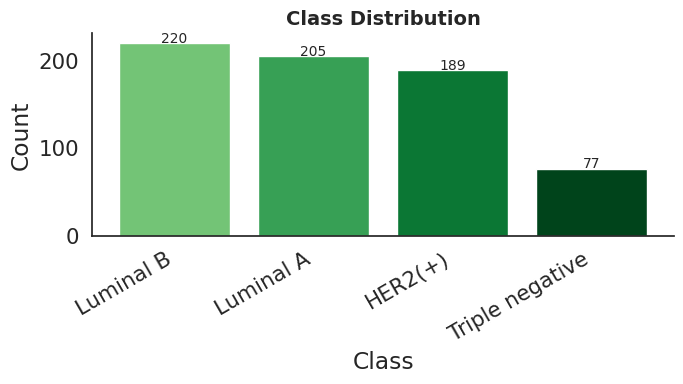

In [ ]:
# @title
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.cm as cm
import numpy as np

# Cleaner font and style
rcParams["font.size"] = 12
rcParams["axes.spines.top"] = False
rcParams["axes.spines.right"] = False

# Count samples per class
counts = labels_df["label"].value_counts()

# Create a green color scale
colors = cm.Greens(np.linspace(0.5, 1, len(counts)))  # medium to light green

# Create figure and axes with transparent background
fig, ax = plt.subplots(figsize=(7, 4), facecolor="none")  # figure transparent
ax.set_facecolor("none")  # axes transparent

# Bar plot
bars = ax.bar(counts.index, counts.values, color=colors)

# Titles and labels
ax.set_title("Class Distribution", fontsize=14, weight="bold")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")

# Add value labels above bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, str(int(height)),
            ha="center", fontsize=10)

plt.tight_layout()

# Save with transparent background
plt.show()


### Display sample

TypeError: Invalid shape (4, 64, 64) for image data

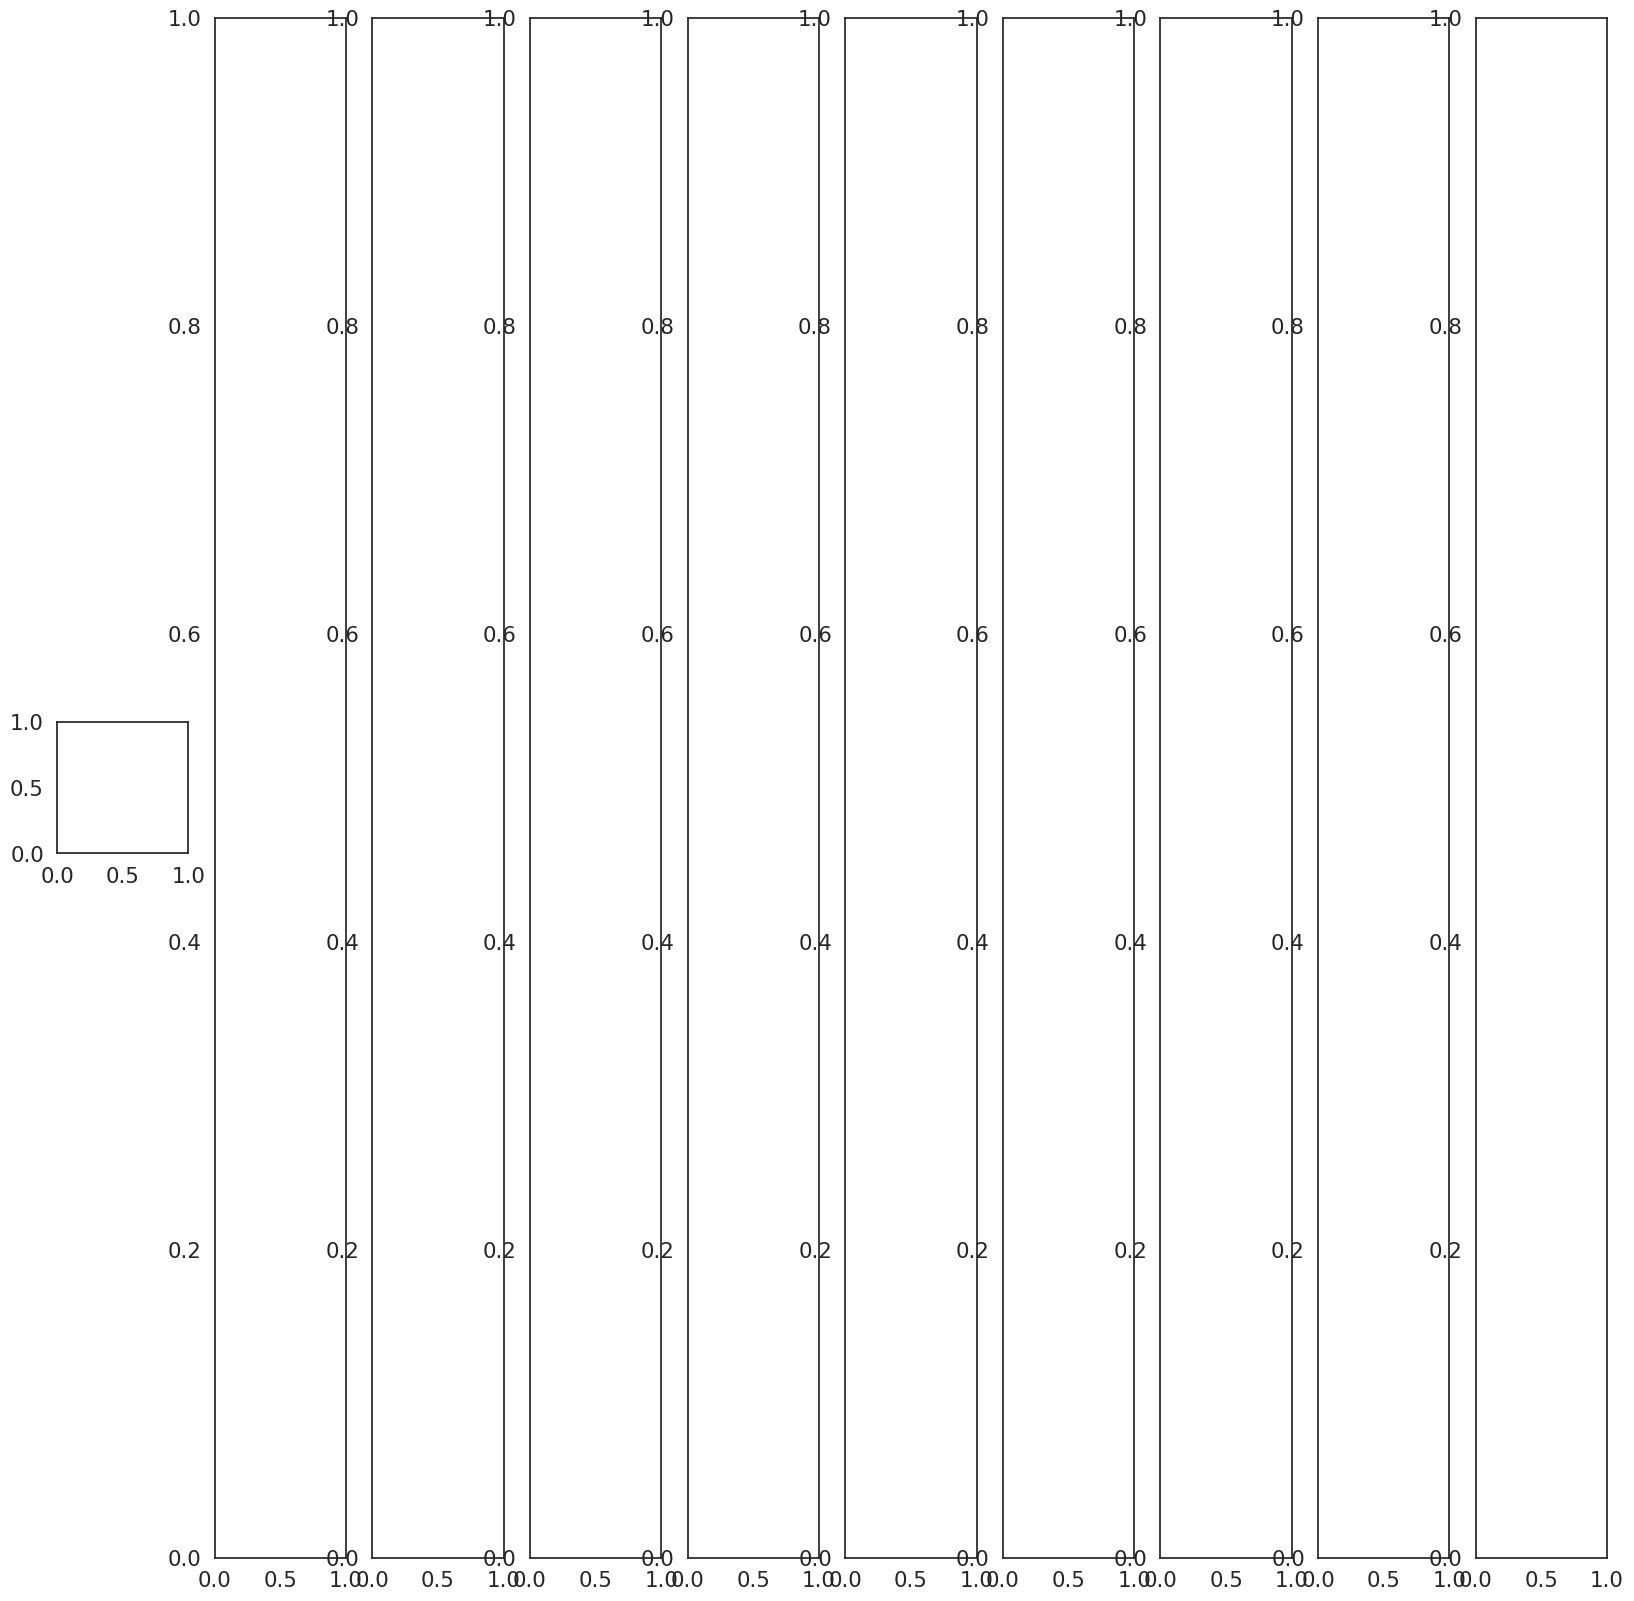

In [ ]:

num_img = 10
random_indices = random.sample(range(len(val_images)), num_img)

fig, axes = plt.subplots(1, num_img, figsize=(20, 20))

# Iterate through the selected number of images
for i, idx in enumerate(random_indices):
    ax = axes[i % num_img]
    ax.imshow(np.squeeze(val_images[idx]), vmin=0., vmax=1.)
    ax.set_title(f'{labels[val_labels[idx][0]]}')
    ax.axis('off')

# Adjust layout and display the images
plt.tight_layout()
plt.show()


## 👁️ **Convolutional Neural Networks**

### 🧮 **Network Parameters**

In [ ]:
# Number of training epochs
LEARNING_RATE = 1e-3
EPOCHS = 100
PATIENCE = 50

# Regularisation
DROPOUT_RATE = 0.3         # Dropout probability
L1_LAMBDA = 0            # L1 penalty
L2_LAMBDA = 0            # L2 penalty

# Set up loss function and optimizer
criterion = nn.CrossEntropyLoss()

# Print the defined parameters
print("Epochs:", EPOCHS)
print("Batch Size:", BATCH_SIZE)
print("Learning Rare:", LEARNING_RATE)
print("Dropout Rate:", DROPOUT_RATE)
print("L1 Penalty:", L1_LAMBDA)
print("L2 Penalty:", L2_LAMBDA)

Epochs: 100
Batch Size: 32
Learning Rare: 0.001
Dropout Rate: 0.3
L1 Penalty: 0
L2 Penalty: 0


In [ ]:
# CNN Architecture parameters
# Number of convolutional blocks
NUM_BLOCKS = 2

# Number of conv layers per block
CONVS_PER_BLOCK = 1

# Use strided convolutions instead of pooling
USE_STRIDE = False

# Stride value when USE_STRIDE is True
STRIDE_VALUE = 2

# Padding size
PADDING_SIZE = 1

# Pooling size when USE_STRIDE is False
POOL_SIZE = 2

# Number of channels in first block
INITIAL_CHANNELS = 32

# Channel multiplication factor between blocks
CHANNEL_MULTIPLIER = 2

print("Num Blocks:", NUM_BLOCKS)
print("Convs per Block:", CONVS_PER_BLOCK)
print("Use Stride:", USE_STRIDE)
print("Stride Value:", STRIDE_VALUE)
print("Padding Size:", PADDING_SIZE)
print("Pool Size:", POOL_SIZE)
print("Initial Channels:", INITIAL_CHANNELS)
print("Channel Multiplier:", CHANNEL_MULTIPLIER)

Num Blocks: 2
Convs per Block: 1
Use Stride: False
Stride Value: 2
Padding Size: 1
Pool Size: 2
Initial Channels: 32
Channel Multiplier: 2


In [ ]:
# Single convolutional block with multiple conv layers, ReLU and pooling/stride
class VanillaCNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_convs=1, use_stride=False, stride_value=2, padding_size=1, pool_size=2):
        super().__init__()

        layers = []

        # First convolution: in_channels -> out_channels
        if num_convs == 1:
            # Single conv: apply stride here if use_stride is True
            stride = stride_value if use_stride else 1
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=padding_size, stride=stride))
        else:
            # Multiple convs: first one always has stride=1
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=1))

            # Intermediate convolutions (all with stride=1)
            for i in range(1, num_convs - 1):
                layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, stride=1))

            # Last convolution: apply stride here if use_stride is True
            stride = stride_value if use_stride else 1
            layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=padding_size, stride=stride))

        # ReLU activation
        layers.append(nn.ReLU())

        # Pooling only if not using stride for spatial reduction
        if not use_stride:
            layers.append(nn.MaxPool2d(kernel_size=pool_size, stride=pool_size))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


# Convolutional Neural Network architecture for CIFAR10 classification
class CNN(nn.Module):
    def __init__(self, input_shape, num_classes=4, dropout_rate=DROPOUT_RATE,
                 num_blocks=NUM_BLOCKS, convs_per_block=CONVS_PER_BLOCK,
                 use_stride=USE_STRIDE, stride_value=STRIDE_VALUE, padding_size=PADDING_SIZE, pool_size=POOL_SIZE,
                 initial_channels=INITIAL_CHANNELS, channel_multiplier=CHANNEL_MULTIPLIER):
        super().__init__()

        # Build convolutional blocks
        blocks = []
        in_channels = input_shape[0]
        out_channels = initial_channels

        for i in range(num_blocks):
            blocks.append(VanillaCNNBlock(
                in_channels=in_channels,
                out_channels=out_channels,
                num_convs=convs_per_block,
                use_stride=use_stride,
                stride_value=stride_value,
                padding_size=padding_size,
                pool_size=pool_size
            ))

            # Prepare for next block: increase channels
            in_channels = out_channels
            out_channels = out_channels * channel_multiplier

        self.features = nn.Sequential(*blocks)

        # Calculate flattened size after all blocks using a dummy forward pass
        # This approach is robust and works with any configuration of padding, stride, and pooling
        with torch.no_grad():
            dummy_input = torch.zeros(1, *input_shape)
            dummy_output = self.features(dummy_input)
            flattened_size = dummy_output.view(1, -1).shape[1]

        # Classification head: flatten features and apply dropout before final layer
        self.classifier_head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(flattened_size, num_classes)
        )

    # Forward pass through the network
    def forward(self, x):
        x = self.features(x)
        x = self.classifier_head(x)
        return x

In [ ]:
sample_image, _ = dataset[0]  # first image

# Define the input shape based on the training data
input_shape = sample_image.shape  # [C, H, W]
print(input_shape)

# Define the number of classes based on the categorical labels
num_classes = len(np.unique(labels_df['label_mapped']))

torch.Size([4, 32, 32])


In [ ]:
# Instantiate CNN model and move to computing device (CPU/GPU)
cnn_model = CNN(
    input_shape,
    num_classes,
    num_blocks=NUM_BLOCKS,
    convs_per_block=CONVS_PER_BLOCK,
    use_stride=USE_STRIDE,
    stride_value=STRIDE_VALUE,
    padding_size=PADDING_SIZE,
    pool_size=POOL_SIZE,
    initial_channels=INITIAL_CHANNELS,
    channel_multiplier=CHANNEL_MULTIPLIER
    ).to(device)

# Display model architecture summary
summary(cnn_model, input_size=input_shape)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]           1,184
              ReLU-2           [-1, 32, 32, 32]               0
         MaxPool2d-3           [-1, 32, 16, 16]               0
   VanillaCNNBlock-4           [-1, 32, 16, 16]               0
            Conv2d-5           [-1, 64, 16, 16]          18,496
              ReLU-6           [-1, 64, 16, 16]               0
         MaxPool2d-7             [-1, 64, 8, 8]               0
   VanillaCNNBlock-8             [-1, 64, 8, 8]               0
           Flatten-9                 [-1, 4096]               0
          Dropout-10                 [-1, 4096]               0
           Linear-11                    [-1, 4]          16,388
Total params: 36,068
Trainable params: 36,068
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.02
Forward/ba

In [ ]:
# Set up TensorBoard logging and save model architecture
experiment_name = "cnn"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x = torch.randn(1, input_shape[0], input_shape[1], input_shape[2]).to(device)
writer.add_graph(cnn_model, x)

# Define optimizer with L2 regularization
optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

### 🧠 **Model Training**

In [ ]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, f1 score) - Training loss and f1 score for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters() if p.requires_grad and p.dim() > 1)
            l2_norm = sum(p.pow(2).sum() for p in model.parameters() if p.requires_grad and p.dim() > 1)

            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm


        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [ ]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note:
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [ ]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """
    Log training metrics and model parameters to TensorBoard for visualization.

    Args:
        writer (SummaryWriter): TensorBoard SummaryWriter object for logging
        epoch (int): Current epoch number (used as x-axis in TensorBoard plots)
        train_loss (float): Training loss for this epoch
        train_f1 (float): Training f1 score for this epoch
        val_loss (float): Validation loss for this epoch
        val_f1 (float): Validation f1 score for this epoch
        model (nn.Module): The neural network model (for logging weights/gradients)

    Note:
        This function logs scalar metrics (loss/f1 score) and histograms of model
        parameters and gradients, which helps monitor training progress and detect
        issues like vanishing/exploding gradients.
    """
    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if the tensor is not empty before adding a histogram
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                # Check if the gradient tensor is not empty before adding a histogram
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [ ]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_f1")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Write metrics to TensorBoard for visualization
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

In [ ]:

%%time
# Train model and track training history
cnn_model, training_history = fit(
    model=cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name="cnn",
    patience=10
    )

# Update best model if current performance is superior
if training_history['val_f1'][-1] > best_performance:
    best_model = cnn_model
    best_performance = max(training_history['val_f1'])

Training 100 epochs...
Epoch   1/100 | Train: Loss=0.9817, F1 Score=0.5364 | Val: Loss=1.3957, F1 Score=0.3157
Epoch   2/100 | Train: Loss=0.9524, F1 Score=0.5770 | Val: Loss=1.4114, F1 Score=0.3611
Epoch   3/100 | Train: Loss=0.9432, F1 Score=0.5915 | Val: Loss=1.4588, F1 Score=0.3620
Epoch   4/100 | Train: Loss=0.9303, F1 Score=0.5843 | Val: Loss=1.4277, F1 Score=0.3355
Epoch   5/100 | Train: Loss=0.9228, F1 Score=0.5835 | Val: Loss=1.4793, F1 Score=0.3367
Epoch   6/100 | Train: Loss=0.8889, F1 Score=0.6091 | Val: Loss=1.4655, F1 Score=0.3742
Epoch   7/100 | Train: Loss=0.8568, F1 Score=0.6141 | Val: Loss=1.5021, F1 Score=0.3223
Epoch   8/100 | Train: Loss=0.8357, F1 Score=0.6271 | Val: Loss=1.5741, F1 Score=0.3258
Epoch   9/100 | Train: Loss=0.8321, F1 Score=0.6647 | Val: Loss=1.5774, F1 Score=0.3189
Epoch  10/100 | Train: Loss=0.8224, F1 Score=0.6257 | Val: Loss=1.5848, F1 Score=0.3475
Epoch  11/100 | Train: Loss=0.7802, F1 Score=0.6596 | Val: Loss=1.6164, F1 Score=0.3060
Epoch  12

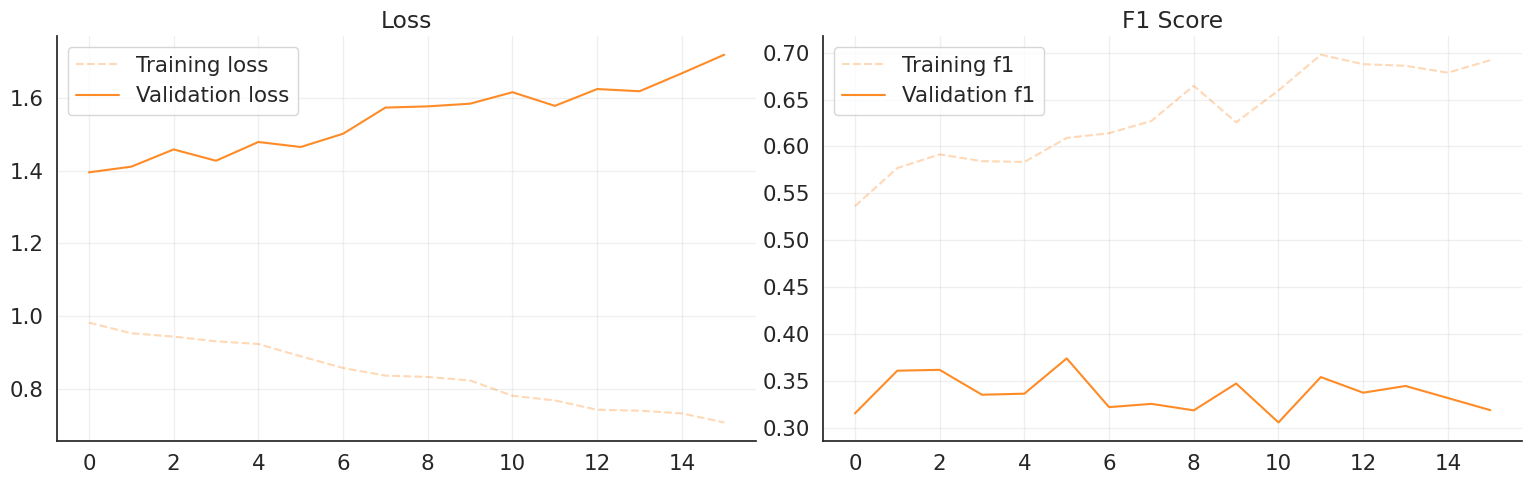

In [ ]:
# @title Plot Hitory
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Accuracy over the validation set: 0.3813
Precision over the validation set: 0.3762
Recall over the validation set: 0.3813
F1 score over the validation set: 0.3742


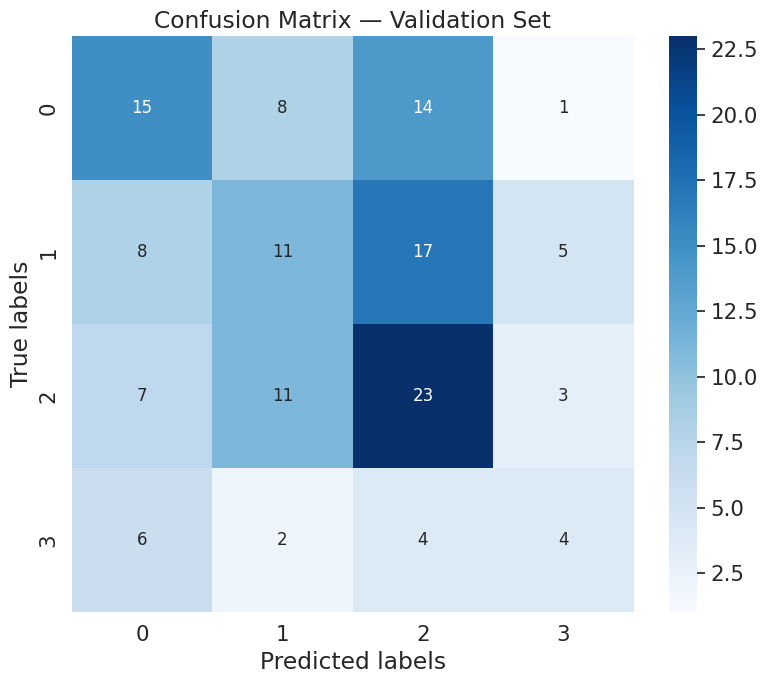

In [ ]:
# @title Plot Confusion Matrix
# Collect predictions and ground truth labels
val_preds, val_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb in val_loader:
        xb = xb.to(device)

        # Forward pass: get model predictions
        logits = cnn_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

## 📤 Create Submission

In [ ]:
val_preds = []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb in submission_loader:
        xb = xb.to(device)

        # Forward pass: get model predictions
        logits = cnn_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)

# Combine all batches
val_preds = np.concatenate(val_preds)

# Map integer predictions to label names
inv_label_mapping = {v: k for k, v in mapping.items()}
submission_labels = np.array([inv_label_mapping[p] for p in val_preds])

# Create DataFrame with sequence-level predictions
output = pd.DataFrame({
    'sample_index': submission_files,
    'label': submission_labels
})
output.head(20)

,sample_index,label
0,img_0000.png,Luminal B
1,img_0001.png,Luminal B
2,img_0002.png,Luminal B
3,img_0003.png,Luminal B
4,img_0004.png,Luminal B
5,img_0005.png,Luminal B
6,img_0006.png,Luminal A
7,img_0007.png,Luminal B
8,img_0008.png,Triple negative
9,img_0009.png,Luminal B


In [ ]:
# Define the filename
filename = "try3_attempt5_from_notebook_"+str(best_performance)+".csv"
if(TRAIN_ON_WHOLE_SET):
  filename = "submission_from_notebook_WHOLE.csv" # removes validation score as it would make no sense

# Remove the file if it already exists
if os.path.exists(filename):
    os.remove(filename)

# Now safely write the new file
output.to_csv(filename, index=False)

## 🛫 Send Submission

In [ ]:
message = "sent automatically from colab notebook"
if SUBMIT_PREDICTION:
    !kaggle competitions submit -c an2dl2526c2v2 -f $filename -m "$message"

100% 10.7k/10.7k [00:00<00:00, 13.8kB/s]
Successfully submitted to AN2DL [2025-2026]: Image Classification 2.0